# Sonata Tutorial Notebook

This notebook is the runnable companion to `docs/tutorial.md`. It follows the Sonata workflow end to end and saves every tutorial figure into `docs/images/` so the PNG files can be regenerated manually.

Run it from either the repository root or the `docs/` directory; the setup cell resolves paths for both locations.


In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sonata as so

# Resolve paths
project_root = Path.cwd()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent

data_dir = project_root / "data"
image_dir = project_root / "docs" / "images"
image_dir.mkdir(parents=True, exist_ok=True)


def save_ax(ax, filename: str) -> None:
    ax.figure.savefig(image_dir / filename, bbox_inches="tight", dpi=160)


def save_axes(axes, filename: str) -> None:
    axes_array = np.asarray(axes, dtype=object).ravel()
    axes_array[0].figure.savefig(image_dir / filename, bbox_inches="tight", dpi=160)

## 1. Data

Load the breast cancer SBS count matrix and sample labels. Rows of the `AnnData` object are samples, and columns are mutation types.


In [2]:
counts = pd.read_csv(data_dir / "hrdetect_counts_training.csv", index_col=0).T
labels = pd.read_csv(data_dir / "hrdetect_labels_training.csv", index_col=0)

adata = ad.AnnData(counts)
adata.obs = adata.obs.join(labels)
adata

AnnData object with n_obs × n_vars = 311 × 96
    obs: 'hrdetect_score', 'hrd_label'

In [3]:
adata.to_df().head()

Type,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
PD10014a,235,241,37,234,244,238,35,243,146,126,...,70,107,32,18,61,78,71,54,76,160
PD11327a,281,229,53,260,284,219,46,264,199,144,...,106,78,28,22,50,55,84,48,111,184
PD11742a,117,100,10,104,113,119,20,101,82,66,...,28,43,12,7,24,27,39,23,51,70
PD11748a,232,178,12,227,230,215,32,207,155,108,...,90,96,38,29,80,72,66,45,106,134
PD11750a,105,92,18,103,129,103,20,131,68,51,...,59,62,25,19,49,38,66,49,71,120


Load the COSMIC SBS catalog as reference signatures.


In [4]:
catalog_sbs = pd.read_csv(
    data_dir / "COSMIC_v3.3.1_SBS_GRCh38.csv",
    index_col=0,
).T
catalog_sbs.head()

Type,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
SBS1,8.760229e-04,0.002220,0.000180,0.001265,0.000305,0.001738,9.195448e-05,2.180221e-16,0.001556,3.293192e-04,...,0.000126,0.000169,2.179179e-16,2.184121e-16,0.000344,1.455855e-05,2.165410e-16,0.000055,0.000578,2.201263e-16
SBS2,5.790059e-07,0.000146,0.000054,0.000098,0.000205,0.000093,2.221443e-16,4.155765e-04,0.000086,2.187235e-16,...,0.000120,0.000203,2.062090e-04,1.315215e-04,0.000037,2.245140e-16,1.637288e-05,0.000071,0.000095,2.222518e-16
SBS3,2.091975e-02,0.016343,0.001808,0.012265,0.022376,0.024992,2.519081e-03,1.531538e-02,0.007144,1.077098e-02,...,0.010698,0.007075,4.393612e-03,2.331305e-03,0.010949,5.913508e-03,7.161182e-03,0.006401,0.008113,1.054309e-02
SBS4,4.245074e-02,0.032990,0.016116,0.029663,0.080269,0.078743,2.459315e-02,6.863345e-02,0.031667,3.439439e-02,...,0.003790,0.001208,5.945388e-04,2.521062e-04,0.002441,2.556565e-04,3.724498e-04,0.000177,0.002339,5.704354e-04
SBS5,1.205205e-02,0.009337,0.001908,0.006636,0.007379,0.006057,3.467616e-03,6.445227e-03,0.010205,7.548778e-03,...,0.006120,0.007336,2.501419e-03,1.701241e-03,0.005316,2.380296e-03,5.148772e-03,0.006677,0.006984,1.353626e-02


## 2. Fit KL-NMF

Fit KL-NMF with six signatures and keep the objective history so convergence can be inspected.


In [5]:
model = so.models.KLNMF(n_signatures=6, init_method="random")
model.fit(
    adata.copy(),
    init_kwargs={"seed": 42},
    history=True
)

In [6]:
model.signatures.head()

Type,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
Sig1,0.019787,1.860484e-02,0.003175,1.902114e-02,0.018502,0.019350,0.002554,0.017063,0.008046,0.011090,...,0.010854,0.009339,4.483434e-03,3.171670e-03,7.859385e-03,6.968846e-03,9.256610e-03,0.006410,0.010971,0.015336
Sig2,0.000550,1.192093e-07,0.000352,1.523354e-07,0.002150,0.001476,0.000539,0.001907,0.002127,0.000161,...,0.000541,0.000515,1.192093e-07,1.192093e-07,1.192093e-07,1.192093e-07,9.268081e-04,0.000372,0.000253,0.001709
Sig3,0.013855,1.109985e-02,0.002502,5.735804e-03,0.005803,0.002638,0.001959,0.003051,0.014460,0.006245,...,0.001242,0.001445,5.181981e-04,1.115916e-03,1.020352e-03,1.081934e-03,4.212582e-03,0.003180,0.003345,0.009378
Sig4,0.008160,1.007933e-02,0.001582,7.107403e-03,0.005220,0.010155,0.001172,0.006484,0.000454,0.007829,...,0.006013,0.004285,2.583766e-03,1.630097e-03,5.023175e-03,3.705892e-03,7.168212e-03,0.003792,0.005900,0.013807
Sig5,0.039931,2.630000e-02,0.003048,2.614050e-02,0.042771,0.021901,0.006080,0.037041,0.043029,0.017723,...,0.002889,0.024221,1.154597e-03,2.904535e-04,1.302309e-03,6.707409e-03,1.192093e-07,0.000895,0.002604,0.011154


In [7]:
model.exposures.head()

,Sig1,Sig2,Sig3,Sig4,Sig5,Sig6
PD10014a,7325.303072,590.708994,6.994876e+02,1199.630900,2.164866e+03,145.003640
PD11327a,7877.070813,922.576660,1.192093e-07,935.133691,2.804379e+03,175.840328
PD11742a,2870.915499,981.901309,5.356673e+02,858.196894,1.216615e+03,541.703938
PD11748a,6905.964405,787.625143,7.127241e+02,1304.901850,1.834184e+03,215.600946
PD11750a,5875.263215,2908.661752,1.210309e+02,827.472271,1.192093e-07,345.571852


In [8]:
model.reconstruction_error

24461.119256330676

## 3. Tutorial Figures


### 3.1 Model Assessment


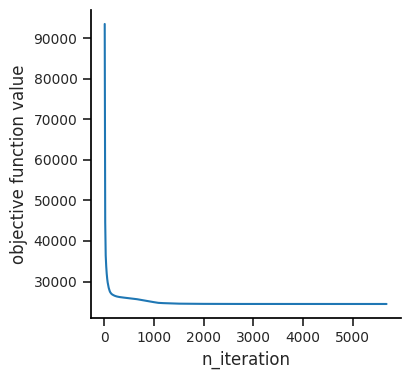

In [9]:
ax = so.pl.history(
    model.history["objective_function"],
    conv_test_freq=model.conv_test_freq,
)
save_ax(ax, "klnmf-history.png")

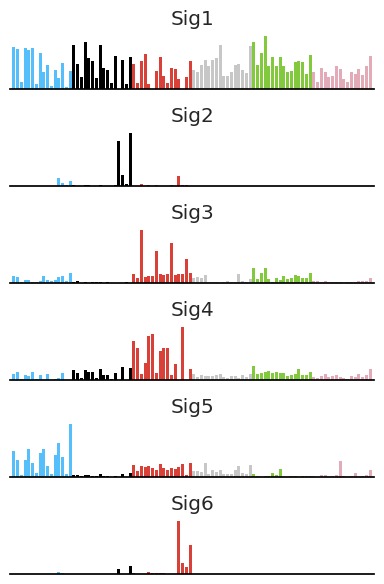

In [10]:
axes = so.pl.barplot(model.asignatures)
save_axes(axes, "klnmf-signatures.png")

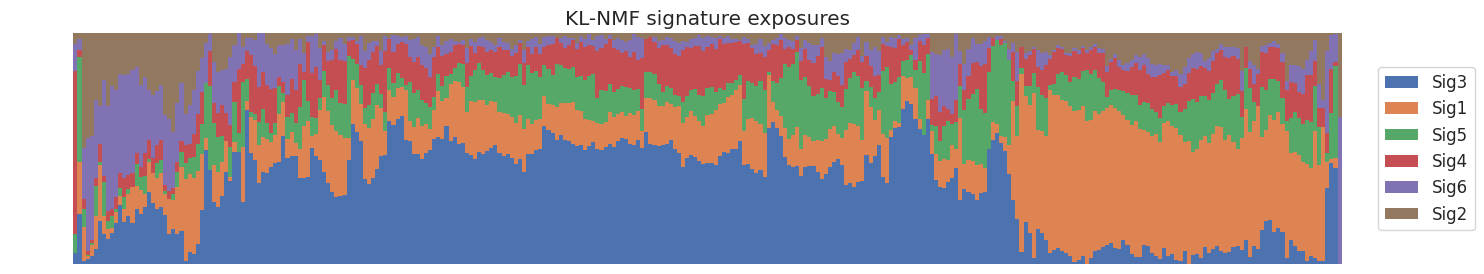

In [11]:
fig, ax = plt.subplots(figsize=(18, 3))
ax = so.pl.stacked_barplot(
    model.exposures,
    reorder_dimensions=True,
    annotate_obs=False,
    title="KL-NMF signature exposures",
    ax=ax,
)
save_ax(ax, "klnmf-exposures.png")

Reduce the dimensionality of the exposures with UMAP and plot the result.


/home/benedikt/miniconda3/envs/sonata_nb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/benedikt/miniconda3/envs/sonata_nb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


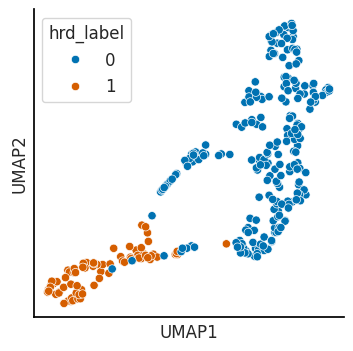

In [12]:
palette = ["#0072b2", "#d55e00"]

so.tl.reduce_dimension(
    model.adata,
    basis="exposures",
    method="umap",
    n_components=2,
    random_state=42,
)
ax = so.pl.embedding(
    model.adata,
    basis="umap",
    hue=adata.obs["hrd_label"],
    palette=palette,
)
save_ax(ax, "klnmf-exposure-umap.png")

Scatter plots can also be customized by storing colors in the `AnnData` object and passing annotation labels explicitly. By default, Sonata adjusts annotations to reduce overlap.


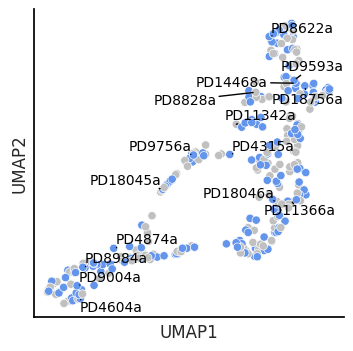

In [13]:
rng = np.random.default_rng(42)
my_colors = ["cornflowerblue", "silver"]
model.adata.obs["my_color"] = rng.choice(my_colors, adata.n_obs)

special_samples = rng.choice(adata.obs_names, 15, replace=False)
annotations = [
    sample if sample in special_samples else ""
    for sample in adata.obs_names
]

ax = so.pl.embedding(
    model.adata,
    "umap",
    color="my_color",
    annotations=annotations,
    adjust_kwargs={"arrowprops": dict(arrowstyle="-", color="k")},
)
save_ax(ax, "klnmf-custom-embedding.png")

### 3.2 Additional Visualization Functionality


Plot a sample-level annotation against the HRDetect score.

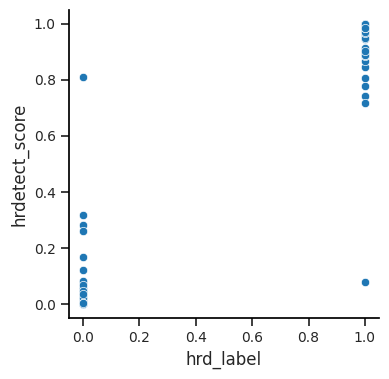

In [14]:
ax = so.pl.scatter(model.adata, x="hrd_label", y="hrdetect_score")
save_ax(ax, "klnmf-hrd-scatter.png")

Compute and plot correlations between samples based on their KL-NMF exposures.

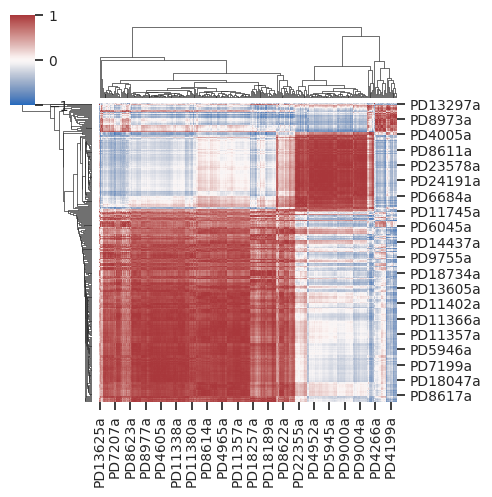

In [15]:
so.tl.correlation(model.adata, basis="exposures")
grid = so.pl.correlation(model.adata, figsize=(5, 5))
grid.figure.savefig(image_dir / "klnmf-sample-correlation.png", bbox_inches="tight", dpi=160)

The same correlation plotting function can be used for learned signatures.

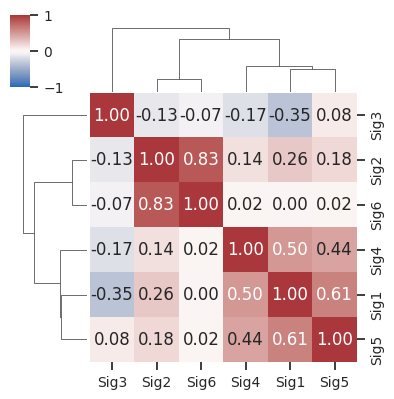

In [16]:
model.asignatures.obsp["correlation"] = so.tl.correlation_numpy(model.adata.obsm["exposures"].T)
grid = so.pl.correlation(
    model.asignatures,
    annot=True,
    figsize=(4, 4),
)
grid.figure.savefig(image_dir / "klnmf-signature-correlation.png", bbox_inches="tight", dpi=160)

## 4. Fixing Known Signatures

Known signatures can be fixed during fitting by passing them through `given_parameters`.


In [17]:
given_asignatures = ad.AnnData(catalog_sbs.loc[["SBS1", "SBS2"]])

model_fixed = so.models.KLNMF(n_signatures=4)
model_fixed.fit(
    adata.copy(),
    given_parameters={"asignatures": given_asignatures},
    init_kwargs={"seed": 42},
)
model_fixed.signatures.head()

Type,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
SBS1,8.760229e-04,0.002220,0.000180,0.001265,0.000305,0.001738,9.195448e-05,1.192093e-07,0.001556,3.293192e-04,...,0.000126,0.000169,1.192093e-07,1.192093e-07,0.000344,1.455855e-05,1.192093e-07,0.000055,0.000578,1.192093e-07
SBS2,5.790059e-07,0.000146,0.000054,0.000098,0.000205,0.000093,1.192093e-07,4.155765e-04,0.000086,1.192093e-07,...,0.000120,0.000203,2.062090e-04,1.315215e-04,0.000037,1.192093e-07,1.637288e-05,0.000071,0.000095,1.192093e-07
Sig1,2.014124e-03,0.001652,0.000236,0.001209,0.002714,0.001885,3.926027e-04,1.731693e-03,0.001233,1.188269e-03,...,0.000475,0.000204,6.681904e-05,4.234365e-05,0.000397,3.272995e-04,8.473892e-04,0.000290,0.000294,1.408924e-03
Sig2,2.252561e-02,0.018625,0.003111,0.016774,0.019610,0.015665,3.185282e-03,1.725415e-02,0.016522,1.180632e-02,...,0.007064,0.010275,2.929428e-03,2.171920e-03,0.005055,5.524885e-03,6.875565e-03,0.004817,0.007643,1.464084e-02


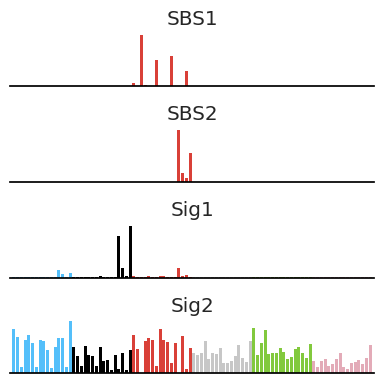

In [18]:
axes = so.pl.barplot(model_fixed.asignatures)
save_axes(axes, "klnmf-fixed-signatures.png")

## 5. CorrNMF

CorrNMF models exposures through sample offsets, signature offsets, and joint sample/signature embeddings.


In [19]:
bdata = adata.copy()
bdata.X = adata.X / adata.X.sum(axis=1, keepdims=True) * 960

In [20]:
corr_model = so.models.CorrNMF(
    n_signatures=6,
    init_method="random",
    max_iterations=3000
)
corr_model.fit(
    bdata,
    init_kwargs={"seed": 42},
    verbose=True,
)

iteration: 1000; objective: -63220.36
iteration: 2000; objective: -62535.26
iteration: 3000; objective: -62480.93


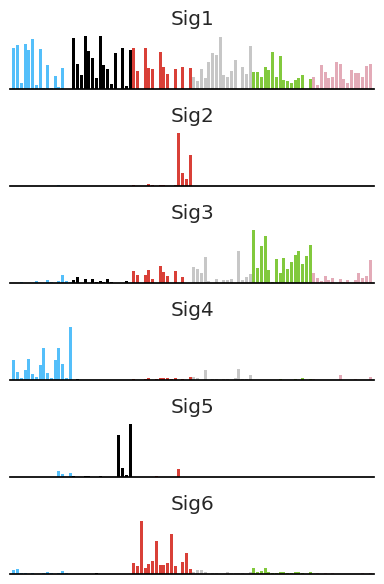

In [21]:
axes = so.pl.barplot(corr_model.asignatures)
save_axes(axes, "corrnmf-signatures.png")

In [22]:
corr_model.asignatures.obs["offsets"]

Sig1    0.655102
Sig2   -0.441767
Sig3    0.278557
Sig4   -0.085507
Sig5   -0.731936
Sig6    0.636127
Name: offsets, dtype: float64

Reduce the dimensionality of sample and signature embeddings jointly with UMAP. Signature points are drawn on top of sample points using explicit z-order annotations, and signature labels are passed to `so.pl.embedding_multiple`.

/home/benedikt/miniconda3/envs/sonata_nb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


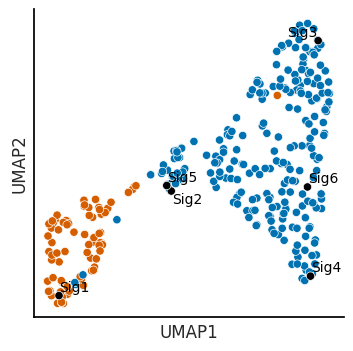

In [23]:
corr_model.adata.obs["color_embeddings"] = np.where(
    corr_model.adata.obs["hrd_label"].astype(bool),
    "#d55e00",
    "#0072b2",
)
corr_model.adata.obs["zorder_embeddings"] = 1
corr_model.asignatures.obs["color_embeddings"] = "black"
corr_model.asignatures.obs["zorder_embeddings"] = 2

so.tl.reduce_dimension_multiple(
    [corr_model.adata, corr_model.asignatures],
    basis="embeddings",
    method="umap",
    n_components=2,
    random_state=42,
)

fig, ax = plt.subplots(figsize=(4, 4))
ax = so.pl.embedding_multiple(
    [corr_model.asignatures, corr_model.adata],
    basis="umap",
    color="color_embeddings",
    zorder="zorder_embeddings",
    annotations=corr_model.signature_names,
    ax=ax,
)
save_ax(ax, "corrnmf-embeddings-umap.png")

## 6. Choosing a Number of Signatures

This simple sweep is a starting point for model selection. For publication-quality analyses, repeat fits across seeds and compare learned signatures against domain knowledge and known catalogs.


In [24]:
results = []

for n_signatures in range(2, 11):
    candidate = so.models.KLNMF(
        n_signatures=n_signatures,
        init_method="random",
    )
    candidate.fit(adata.copy(), init_kwargs={"seed": 42})
    results.append(
        {
            "n_signatures": n_signatures,
            "reconstruction_error": candidate.reconstruction_error,
        }
    )

results = pd.DataFrame(results)

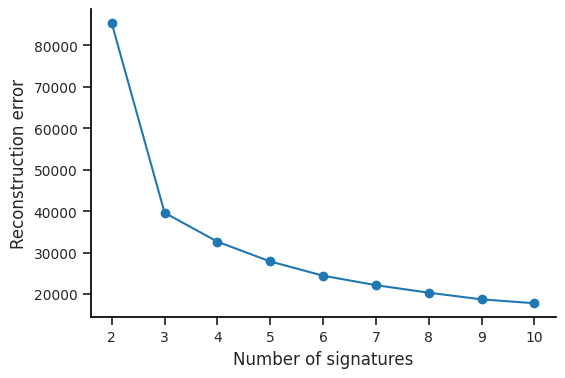

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(results["n_signatures"], results["reconstruction_error"], marker="o")
ax.set_xlabel("Number of signatures")
ax.set_ylabel("Reconstruction error")
save_ax(ax, "model-selection-reconstruction-error.png")